# Section 3 - NLP Chatbot Model Training

In [1]:
import os
# Run from project root so data/, models/, reports/ resolve correctly
if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")
print("Working directory:", os.getcwd())

Working directory: c:\Users\LENOVO\BLYS_Task


## 3.1 - Expand Intent Training Dataset

Adds training examples for all intents including availability, greetings, and out-of-scope queries.

In [2]:
import json, random, pandas as pd
random.seed(42)

# â”€â”€ Intent training corpus â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
# Designed to challenge semantic understanding:
#   - paraphrases with completely different surface forms
#   - informal / abbreviated language
#   - multi-slot single messages
#   - ambiguous short replies (resolved by context at inference time)

INTENT_EXAMPLES = {

    "reschedule": [
        "Can I reschedule my booking?",
        "I want to reschedule my appointment",
        "Is it possible to change my booking date?",
        "I need to move my booking to a different time",
        "Can you help me reschedule?",
        "I want to change the time of my appointment",
        "Need to reschedule my massage",
        "Can I shift my booking?",
        "I would like to reschedule please",
        "How do I reschedule my session?",
        "Change my booking to another time",
        "Move my appointment to another day",
        "I need to push my appointment back",
        "Can I pick a different time slot?",
        "Let me change when my booking is",
        "I want a different appointment time",
        "Shift my massage to next week",
        "Can we move this to Friday instead?",
        "I need to delay my appointment",
        "Swap my booking time",
        "Change the date of my session please",
        "I'd like to alter my appointment",
        "Push back my booking by a day",
        "I want to modify my appointment time",
        "Can I change when I'm booked in?",
        "What is the process of rescheduling?",
        "How does rescheduling work?",
        "How do I change my booking date?",
        "Can you explain how to reschedule?",
        "What are the steps to reschedule?",
        "Tell me about rescheduling",
        "Is rescheduling free?",
        "How do I reschedule an appointment?",
    ],

    "cancel": [
        "I want to cancel my booking",
        "Please cancel my appointment",
        "Can you cancel my session?",
        "I need to cancel",
        "Cancel my massage",
        "I'd like to cancel my reservation",
        "Can I cancel my appointment?",
        "Please remove my booking",
        "I want to cancel my session",
        "Cancel my upcoming appointment",
        "I don't want the booking anymore",
        "Scrap my appointment",
        "I need to call off my session",
        "Can I get rid of my booking?",
        "Please delete my appointment",
        "I want to back out of my booking",
        "I've changed my mind, cancel please",
        "Kill my appointment",
        "I won't be needing the booking",
        "Call off the session please",
        "I want to withdraw my booking",
        "Can you remove my appointment?",
        "What is the cancellation process?",
        "How do I cancel my booking?",
        "How does cancellation work?",
        "Is there a cancellation fee?",
        "Can I cancel for free?",
    ],

    "check_booking_status": [
        "What time is my booking?",
        "When is my appointment?",
        "Can you check my booking?",
        "What's the status of my booking?",
        "Look up my appointment please",
        "What's my booking details?",
        "Show me my booking",
        "Can I see my appointment details?",
        "What's scheduled for me?",
        "Give me my booking info",
        "I want to check my reservation",
        "Pull up my booking",
        "Details of my appointment please",
        "What do I have booked?",
        "Check my session status",
        "When is my massage scheduled?",
        "What day is my appointment?",
        "Confirm my booking details",
        "I'd like to review my booking",
        "Can you find my appointment?",
        "Is my booking still confirmed?",
        "What time did I book?",
        "When am I booked in?",
    ],

    "price_inquiry": [
        "How much does a massage cost?",
        "What are your prices?",
        "How much is a facial?",
        "What's the cost of a wellness package?",
        "Can you tell me the price?",
        "What do you charge for a body scrub?",
        "How much for a hair spa treatment?",
        "What are the rates for massage?",
        "Give me a price list",
        "How much does it cost?",
        "What's the fee for a facial?",
        "Tell me about your pricing",
        "What does a spa treatment cost?",
        "How expensive is a massage?",
        "Price of body scrub please",
        "What's your cheapest service?",
        "How much is the wellness package?",
        "Cost of a hair spa?",
        "What do you charge?",
        "Is a facial expensive?",
        "What is the price of spa?",
        "How much for massage?",
        "Pricing for facial?",
        "What services do you offer?",
        "How much would a massage set me back?",
        "Are massages expensive here?",
        "What is included in the wellness package?",
    ],

    "booking_create": [
        "I want to book a massage",
        "Can I make an appointment?",
        "I'd like to schedule a facial",
        "Book me in for a body scrub",
        "I want to make a booking",
        "Can I book a session?",
        "Schedule a wellness package for me",
        "I'd like to book a hair spa",
        "Make me an appointment please",
        "I want to reserve a time slot",
        "Can I get an appointment?",
        "Set up a booking for me",
        "I need to book a service",
        "Create a new booking please",
        "I want to arrange a massage",
        "Book a facial for me",
        "I'd like to get a treatment",
        "Make a reservation for a massage",
        "Can I set up an appointment?",
        "I want to get booked in",
        "Arrange a session please",
        "I need an appointment",
    ],

    "confirmation_yes": [
        "Yes", "Yes please", "Yep", "Yeah", "Confirm",
        "That's correct", "Sounds good", "Sure", "Absolutely",
        "Go ahead", "Please do", "That's right", "Correct",
        "Definitely", "Yes that's fine", "OK", "Ok",
        "Alright", "Perfect", "Yes confirm it",
        "Do it", "Proceed", "Yes go ahead", "That works",
    ],

    "confirmation_no": [
        "No", "No thanks", "Nope", "Cancel that",
        "Don't do that", "Negative", "No don't",
        "Stop", "Never mind", "Forget it",
        "Actually no", "No I don't want to", "Not now",
        "Skip it", "Discard", "No cancel", "That's wrong",
        "Incorrect", "Actually forget it", "No that's not right",
    ],

    "provide_datetime": [
        "Tomorrow at 3pm",
        "Next Monday at 10am",
        "This Friday at 2 in the afternoon",
        "March 30th at noon",
        "Next week Wednesday morning",
        "Saturday at 11am",
        "April 5th 9am",
        "How about Tuesday evening?",
        "Can we do next Thursday at 4?",
        "Morning of the 15th",
        "I'm free Sunday afternoon",
        "2pm tomorrow works",
        "Next available slot please",
        "Any time next week",
        "First thing in the morning",
        "End of this week",
        "Friday noon",
        "In the morning",
        "3 o'clock tomorrow",
        "Next Monday works for me",
    ],

    "provide_booking_id": [
        "BK-001", "BK-002", "BK-003",
        "My booking ID is BK-001",
        "It's BK-002",
        "Reference number BK-003",
        "The ID is BK-001",
        "Booking BK-002",
        "BK001", "BK002",
        "My reference is BK-003",
        "Here's my ID: BK-001",
        "Booking number is BK-002",
        "BK 001", "BK 002",
        "The booking is BK-003",
        "It's booking BK-001",
        "My confirmation is BK-002",
    ],

    "greeting": [
        "Hello", "Hi", "Hey", "Good morning", "Good afternoon",
        "Hi there", "Hey there", "Howdy", "Greetings",
        "Hello there", "Hi Blys", "Hey Blys", "Good day",
        "Morning", "Afternoon", "Evening", "What's up",
    ],

    "goodbye": [
        "Goodbye", "Bye", "See you", "Thanks bye",
        "That's all", "I'm done", "Thanks", "Thank you",
        "Cheers", "All good thanks", "That's everything",
        "No more questions", "Done thanks", "Bye bye",
        "See ya", "That'll be all", "Have a good day",
    ],

    "availability_inquiry": [
        "What dates are available?",
        "What is the available date?",
        "When can I book?",
        "Are you available this weekend?",
        "What slots do you have?",
        "Is there availability tomorrow?",
        "When are you free?",
        "Check availability please",
        "Do you have any openings?",
        "What times are available?",
        "Are there any slots this week?",
        "When is the next available appointment?",
        "What days are you open?",
        "Do you have availability on Saturday?",
        "What are your available hours?",
        "Is Friday available?",
        "Can I book for next week?",
        "Any availability this afternoon?",
        "When can I get an appointment?",
        "Show me available slots",
    ],

    "out_of_scope": [
        "What's the weather like?",
        "Can you recommend a restaurant?",
        "What is AI?",
        "Tell me a joke",
        "How are you?",
        "What can you do?",
        "Who made you?",
        "What time is it?",
        "Do you speak Spanish?",
        "What's today's date?",
        "Where are you located?",
        "Can I talk to a human?",
        "How old are you?",
        "What's your name?",
        "Do you have gift cards?",
        "What is your refund policy?",
        "Are your therapists certified?",
        "How long is a session?",
        "Do you offer memberships?",
        "Is there a loyalty program?",
        "Can I request a specific therapist?",
        "What should I wear during the session?",
        "Do you come to my house?",
        "How do I contact support?",
        "What are your business hours?",
        "Do you offer couple's massage?",
        "Can I tip the therapist?",
        "Is parking available?",
        "Do you have wheelchair access?",
        "I'm not sure what I want",
        "Hmm",
        "I",
        "Maybe",
        "I don't know",
        "Can you do something else?",
        "This is terrible service",
        "I want to speak to a manager",
        "Your prices are too high",
        "I hate this app",
        "Hello there, how's your day?",
        "Tell me something interesting",
        "What's 2 plus 2?",
        "Play some music",
        "Remind me tomorrow",
        "Order me a pizza",
        "Call a taxi",
        "What movies are on tonight?",
        "How do I lose weight?",
        "Give me a recipe",
        "Translate this to French",
        "What is the capital of France?",
        "How do I update my email address?",
        "I forgot my password",
        "Can you send me an invoice?",
    ],
}

# â”€â”€ Build flat DataFrame â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
rows = [{"text": text, "intent": intent}
        for intent, examples in INTENT_EXAMPLES.items()
        for text in examples]
random.shuffle(rows)
df_intents = pd.DataFrame(rows)

print(f"Total training examples : {len(df_intents)}")
print()
print(df_intents["intent"].value_counts().to_string())

Total training examples : 322

intent
out_of_scope            54
reschedule              33
price_inquiry           27
cancel                  27
confirmation_yes        24
check_booking_status    23
booking_create          22
confirmation_no         20
provide_datetime        20
availability_inquiry    20
provide_booking_id      18
greeting                17
goodbye                 17


## 3.2 - Intent Classifier

Trains a Logistic Regression classifier on sentence embeddings from the all-MiniLM-L6-v2 model. Sentence embeddings capture meaning rather than exact words, so phrases like "move my appointment" and "reschedule booking" are treated as similar.

In [3]:
from sentence_transformers import SentenceTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.metrics import classification_report, precision_score, recall_score, f1_score
import numpy as np
import warnings
warnings.filterwarnings("ignore")

# â”€â”€ Label encoding â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
le_intent = LabelEncoder()
X_text    = df_intents["text"].values
y_label   = le_intent.fit_transform(df_intents["intent"].values)
INTENTS   = list(le_intent.classes_)
print("Intents:", INTENTS)
print(f"Training examples: {len(X_text)}")

# â”€â”€ Load Sentence Transformer â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
# all-MiniLM-L6-v2 : Apache-2.0 licence, ~80 MB, 384-dim embeddings
# Downloads once to ~/.cache/huggingface/hub/ â€” subsequent loads are instant
ST_MODEL_NAME = "all-MiniLM-L6-v2"
print(f"\nLoading {ST_MODEL_NAME} (downloads ~80 MB on first run) â€¦")
st_model = SentenceTransformer(ST_MODEL_NAME)

# â”€â”€ Encode training corpus â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
print("Encoding training examples â€¦")
X_emb = st_model.encode(
    X_text.tolist(),
    batch_size=64,
    show_progress_bar=True,
    normalize_embeddings=True,   # L2-normalised â†’ cosine similarity = dot product
)
print(f"Embedding matrix: {X_emb.shape}")   # (n_examples, 384)

# â”€â”€ Logistic Regression on semantic embeddings â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
# C=5.0 gives a softer boundary â€” better for out-of-distribution queries
clf = LogisticRegression(max_iter=2000, C=5.0, random_state=42)
clf.fit(X_emb, y_label)

# â”€â”€ 5-fold cross-validation â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
cv    = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_f1 = cross_val_score(clf, X_emb, y_label, cv=cv, scoring="f1_weighted")
print(f"\nCross-val F1 (5-fold): {cv_f1.mean():.4f} Â± {cv_f1.std():.4f}")

# â”€â”€ Context-aware encoding helper â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
def encode_query(message: str, state_name: str = "IDLE",
                 last_bot: str = "", last_user: str = "") -> np.ndarray:
    """
    Build a context-enriched string and encode it.

    Prepending state + prior turns gives the model information that resolves
    ambiguous short messages:
      "Yes" alone â†’ uncertain
      "[STATE:RESCHEDULE_CONFIRM] [BOT:Reschedule BK-001 to Apr 5?] Yes" â†’ clear
    """
    parts = [f"[STATE:{state_name}]"]
    if last_bot:
        parts.append(f"[BOT:{last_bot[:120]}]")
    if last_user:
        parts.append(f"[PREV:{last_user[:80]}]")
    parts.append(message)
    context_str = " ".join(parts)
    return st_model.encode([context_str], normalize_embeddings=True)[0]

# â”€â”€ State-conditioned priors â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
# Each state defines a probability distribution over intents.
# These are blended (alpha=0.3) with the classifier output â†’ Bayesian combination.
STATE_PRIORS: dict[str, dict[str, float]] = {
    "IDLE": {
        "greeting":             0.10,
        "goodbye":              0.05,
        "booking_create":       0.15,
        "price_inquiry":        0.10,
        "availability_inquiry": 0.10,
        "check_booking_status": 0.10,
        "reschedule":           0.10,
        "cancel":               0.10,
        "out_of_scope":         0.20,
    },
    "RESCHEDULE_ASK_BK_ID": {
        "provide_booking_id": 0.60,
        "confirmation_yes":   0.15,
        "confirmation_no":    0.15,
        "reschedule":         0.10,
    },
    "RESCHEDULE_ASK_DT": {
        "provide_datetime":   0.75,
        "confirmation_no":    0.15,
        "out_of_scope":       0.10,
    },
    "RESCHEDULE_CONFIRM": {
        "confirmation_yes":   0.50,
        "confirmation_no":    0.45,
        "out_of_scope":       0.05,
    },
    "CANCEL_ASK_BK_ID": {
        "provide_booking_id": 0.65,
        "confirmation_no":    0.20,
        "cancel":             0.15,
    },
    "CANCEL_CONFIRM": {
        "confirmation_yes":   0.50,
        "confirmation_no":    0.45,
        "out_of_scope":       0.05,
    },
    "STATUS_ASK_BK_ID": {
        "provide_booking_id": 0.80,
        "confirmation_no":    0.15,
        "out_of_scope":       0.05,
    },
    "PRICE_SHOWN": {
        "confirmation_yes":   0.45,
        "booking_create":     0.25,
        "confirmation_no":    0.25,
        "out_of_scope":       0.05,
    },
    "BOOKING_ASK_SERVICE": {
        "booking_create":     0.55,
        "price_inquiry":      0.25,
        "confirmation_no":    0.15,
        "out_of_scope":       0.05,
    },
    "BOOKING_ASK_DT": {
        "provide_datetime":   0.80,
        "confirmation_no":    0.15,
        "out_of_scope":       0.05,
    },
    "BOOKING_CONFIRM": {
        "confirmation_yes":   0.50,
        "confirmation_no":    0.45,
        "out_of_scope":       0.05,
    },
    "AVAIL_SHOWN": {
        "confirmation_yes":   0.45,
        "booking_create":     0.25,
        "confirmation_no":    0.25,
        "out_of_scope":       0.05,
    },
}

PRIOR_ALPHA = 0.30   # weight given to state prior (0 = ignore prior, 1 = ignore classifier)

def classify_with_context(message: str, state_name: str = "IDLE",
                           last_bot: str = "", last_user: str = "",
                           threshold: float = 0.35) -> tuple[str, float]:
    """
    Encode message with context â†’ logistic regression â†’ state prior blend â†’ intent.
    """
    emb   = encode_query(message, state_name, last_bot, last_user)
    proba = clf.predict_proba([emb])[0]

    # Apply state-conditioned prior
    prior = STATE_PRIORS.get(state_name, {})
    if prior:
        prior_vec = np.array([prior.get(i, 0.01) for i in INTENTS], dtype=float)
        prior_vec /= prior_vec.sum()
        proba = (1 - PRIOR_ALPHA) * proba + PRIOR_ALPHA * prior_vec
        proba /= proba.sum()

    idx    = int(proba.argmax())
    conf   = float(proba[idx])
    intent = le_intent.inverse_transform([idx])[0] if conf >= threshold else "out_of_scope"
    return intent, conf

# â”€â”€ Quick sanity check â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
test_cases = [
    ("move my appointment to friday",      "IDLE",              ""),
    ("shift the session",                  "IDLE",              ""),
    ("Yes",                                "RESCHEDULE_CONFIRM","Reschedule BK-001 to Apr 5? Confirm?"),
    ("BK-001",                             "CANCEL_ASK_BK_ID",  "Please provide your booking ID."),
    ("what time is my massage?",           "IDLE",              ""),
    ("what is the price of spa",           "IDLE",              ""),
]
print(f"\n{'Message':<40} {'State':<22} {'Intent':<25} {'Conf'}")
print("-" * 100)
for msg, state, last_bot in test_cases:
    intent, conf = classify_with_context(msg, state, last_bot)
    print(f"{msg:<40} {state:<22} {intent:<25} {conf:.3f}")

Intents: ['availability_inquiry', 'booking_create', 'cancel', 'check_booking_status', 'confirmation_no', 'confirmation_yes', 'goodbye', 'greeting', 'out_of_scope', 'price_inquiry', 'provide_booking_id', 'provide_datetime', 'reschedule']
Training examples: 322

Loading all-MiniLM-L6-v2 (downloads ~80 MB on first run) â€¦


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Encoding training examples â€¦


Batches:   0%|          | 0/6 [00:00<?, ?it/s]

Embedding matrix: (322, 384)

Cross-val F1 (5-fold): 0.8622 Â± 0.0191

Message                                  State                  Intent                    Conf
----------------------------------------------------------------------------------------------------
move my appointment to friday            IDLE                   reschedule                0.537
shift the session                        IDLE                   out_of_scope              0.340
Yes                                      RESCHEDULE_CONFIRM     out_of_scope              0.292
BK-001                                   CANCEL_ASK_BK_ID       provide_booking_id        0.385
what time is my massage?                 IDLE                   out_of_scope              0.260
what is the price of spa                 IDLE                   price_inquiry             0.623


## 3.3 - Entity Extractor

Extracts booking IDs, dates, times, and service names from user messages using spaCy, dateparser, and regex patterns.

In [4]:
import re
import dateparser
import spacy
from datetime import datetime

# Load spaCy â€” downloads automatically if not present
try:
    nlp = spacy.load("en_core_web_sm")
except OSError:
    import subprocess, sys
    subprocess.run([sys.executable, "-m", "spacy", "download", "en_core_web_sm"], check=True)
    nlp = spacy.load("en_core_web_sm")

# Known services gazetteer
SERVICES = ["massage", "facial", "body scrub", "hair spa",
            "wellness package", "deep tissue", "swedish massage",
            "hot stone", "aromatherapy"]

BOOKING_ID_RE = re.compile(r"BK[-\s]?\d+(?:-\d+)?", re.IGNORECASE)


def extract_entities(text: str) -> dict:
    """Extract booking_id, datetime, service_type from user message."""
    entities = {
        "booking_id":   None,
        "datetime_str": None,
        "datetime_dt":  None,
        "service_type": None,
    }

    # 1. Booking ID (regex)
    bk_match = BOOKING_ID_RE.search(text)
    if bk_match:
        entities["booking_id"] = bk_match.group().upper().replace(" ", "-")

    # 2. Date/time (dateparser â€” handles "30 Mar 2025 10am", "tomorrow", "next Monday")
    dt = dateparser.parse(
        text,
        settings={
            "PREFER_DATES_FROM": "future",
            "RETURN_AS_TIMEZONE_AWARE": False,
        }
    )
    if dt:
        entities["datetime_str"] = dt.strftime("%d %b %Y %I:%M %p")
        entities["datetime_dt"]  = dt

    # 3. Service type (gazetteer match)
    text_lower = text.lower()
    for svc in SERVICES:
        if svc in text_lower:
            entities["service_type"] = svc.title()
            break

    # 4. spaCy fallback for dates not caught by dateparser
    if not entities["datetime_dt"]:
        doc = nlp(text)
        for ent in doc.ents:
            if ent.label_ in ("DATE", "TIME"):
                dt_fallback = dateparser.parse(
                    ent.text,
                    settings={"PREFER_DATES_FROM": "future"}
                )
                if dt_fallback:
                    entities["datetime_str"] = dt_fallback.strftime("%d %b %Y %I:%M %p")
                    entities["datetime_dt"]  = dt_fallback
                    break

    return entities


# Quick tests
test_msgs = [
    "Reschedule BK-001 to 30 Mar 2025 10am",
    "Cancel my massage booking",
    "Next Monday at 3pm please",
    "My ID is BK-2025-042",
    "Tomorrow morning",
]
header = "Message"
print(f"{header:<45} | booking_id | datetime_str")
print("-"*80)
for msg in test_msgs:
    ent = extract_entities(msg)
    print(f"{msg:<45} | {str(ent['booking_id']):<10} | {ent['datetime_str']}")

Message                                       | booking_id | datetime_str
--------------------------------------------------------------------------------
Reschedule BK-001 to 30 Mar 2025 10am         | BK-001     | 05 Apr 2026 10:00 AM
Cancel my massage booking                     | None       | None
Next Monday at 3pm please                     | None       | None
My ID is BK-2025-042                          | BK-2025-042 | None
Tomorrow morning                              | None       | None


## 3.4 - Mock Booking Database

Defines a set of sample bookings used to test reschedule, cancel, and status actions.

In [5]:
from dataclasses import dataclass
from typing import Optional
from datetime import datetime

@dataclass
class Booking:
    booking_id:   str
    customer_id:  int
    service:      str
    scheduled_at: datetime
    status:       str = "confirmed"
    therapist:    str = "Sarah"


MOCK_DB: dict[str, Booking] = {
    "BK-001": Booking("BK-001", 1001, "Swedish Massage",  datetime(2025, 3, 28, 10, 0), therapist="Sarah"),
    "BK-002": Booking("BK-002", 1002, "Facial",           datetime(2025, 4,  2, 14, 0), therapist="Emma"),
    "BK-003": Booking("BK-003", 1003, "Deep Tissue",      datetime(2025, 4,  5,  9, 0), therapist="James"),
    "BK-004": Booking("BK-004", 1004, "Body Scrub",       datetime(2025, 4, 10, 11, 0), therapist="Mia"),
    "BK-005": Booking("BK-005", 1005, "Hair Spa",         datetime(2025, 4, 12, 15, 0), therapist="Lena"),
    "BK-006": Booking("BK-006", 1006, "Wellness Package", datetime(2025, 4, 15, 13, 0), therapist="Tom"),
    "BK-007": Booking("BK-007", 1007, "Hot Stone Massage",datetime(2025, 4, 18, 10, 0), therapist="Sarah"),
    "BK-008": Booking("BK-008", 1008, "Aromatherapy",     datetime(2025, 4, 20, 16, 0), therapist="Emma"),
    "BK-009": Booking("BK-009", 1009, "Swedish Massage",  datetime(2025, 4, 22,  9, 0), therapist="James"),
    "BK-010": Booking("BK-010", 1010, "Facial",           datetime(2025, 4, 25, 14, 0), therapist="Mia"),
}

PRICE_LIST = {
    "Massage":          "$80 â€“ $150  (60â€“90 min)",
    "Swedish Massage":  "$80  (60 min)  |  $120 (90 min)",
    "Deep Tissue":      "$100 (60 min)  |  $140 (90 min)",
    "Hot Stone Massage":"$110 (60 min)  |  $150 (90 min)",
    "Aromatherapy":     "$90  (60 min)  |  $130 (90 min)",
    "Facial":           "$90 â€“ $130",
    "Body Scrub":       "$70 â€“ $110",
    "Hair Spa":         "$60 â€“ $90",
    "Wellness Package": "$180 â€“ $250 (includes 2+ services)",
}


def action_reschedule(booking_id: str, new_dt: datetime) -> dict:
    if booking_id not in MOCK_DB:
        return {"success": False, "message": f"Booking {booking_id} not found."}
    b = MOCK_DB[booking_id]
    old_dt = b.scheduled_at
    b.scheduled_at = new_dt
    b.status = "rescheduled"
    return {"success": True, "booking_id": booking_id, "service": b.service,
            "old_time": old_dt.strftime("%d %b %Y %I:%M %p"),
            "new_time": new_dt.strftime("%d %b %Y %I:%M %p"), "therapist": b.therapist}


def action_cancel(booking_id: str) -> dict:
    if booking_id not in MOCK_DB:
        return {"success": False, "message": f"Booking {booking_id} not found."}
    b = MOCK_DB[booking_id]
    b.status = "cancelled"
    return {"success": True, "booking_id": booking_id, "service": b.service}


def action_get_price(service: Optional[str] = None) -> dict:
    if service:
        key = next((k for k in PRICE_LIST if service.lower() in k.lower()), None)
        if key:
            return {"success": True, "service": key, "price": PRICE_LIST[key]}
    return {"success": True, "all_prices": PRICE_LIST}


def action_get_status(booking_id: str) -> dict:
    if booking_id not in MOCK_DB:
        return {"success": False, "message": f"Booking {booking_id} not found."}
    b = MOCK_DB[booking_id]
    return {
        "success":    True,
        "booking_id": booking_id,
        "service":    b.service,
        "status":     b.status,
        "scheduled_at": b.scheduled_at.strftime("%d %b %Y %I:%M %p"),
        "therapist":  b.therapist,
    }


print(f"Mock DB: {len(MOCK_DB)} bookings â€” {list(MOCK_DB.keys())}")
print(f"Price list: {len(PRICE_LIST)} services")

Mock DB: 10 bookings â€” ['BK-001', 'BK-002', 'BK-003', 'BK-004', 'BK-005', 'BK-006', 'BK-007', 'BK-008', 'BK-009', 'BK-010']
Price list: 9 services


## 3.5 - Dialogue State Machine

Manages multi-turn conversation flow. Each intent maps to a state that determines what the bot asks or does next.

In [6]:
from enum import Enum, auto

class State(Enum):
    IDLE                  = auto()
    RESCHEDULE_ASK_BK_ID  = auto()
    RESCHEDULE_ASK_DT     = auto()
    RESCHEDULE_CONFIRM    = auto()
    CANCEL_ASK_BK_ID      = auto()
    CANCEL_CONFIRM        = auto()
    STATUS_ASK_BK_ID      = auto()   # NEW â€” check booking status
    PRICE_SHOWN           = auto()
    BOOKING_ASK_SERVICE   = auto()
    BOOKING_ASK_DT        = auto()
    BOOKING_CONFIRM       = auto()
    AVAIL_SHOWN           = auto()
    DONE                  = auto()



# Intents answered immediately regardless of current FSM state
GLOBAL_INTERRUPT_INTENTS = frozenset({
    "availability_inquiry",
    "greeting",
    "goodbye",
    "price_inquiry",
    "reschedule",
    "cancel",
    "check_booking_status",
    "booking_create",
    "out_of_scope",
})

RESPONSE_TEMPLATES = {
    "reschedule_offer_help": "Yes, you can reschedule your booking through the Blys app. Would you like me to assist you?",
    "reschedule_ask_bk_id":  "Sure! Please provide your booking ID (e.g. BK-001).",
    "reschedule_ask_dt":     "Please provide the new date and time you would like to reschedule your booking to.",
    "reschedule_confirm":    "Got it. Reschedule booking {booking_id} to {new_time}. Shall I confirm this? (yes / no)",
    "reschedule_success":    "Sent reschedule information to {therapist}. You will get notified once it's confirmed. âœ…",
    "reschedule_cancelled":  "No problem, the reschedule was not sent. Is there anything else I can help with?",

    "cancel_offer_help":  "I can help you cancel your booking. Please provide your booking ID.",
    "cancel_confirm":     "I found booking {booking_id} â€” {service} on {scheduled_at} with {therapist}. Are you sure you want to cancel? (yes / no)",
    "cancel_success":     "Your {service} booking ({booking_id}) has been successfully cancelled. You will receive a confirmation shortly. âœ…",
    "cancel_aborted":     "No problem, your booking has not been cancelled. Is there anything else I can help with?",

    "status_ask_bk_id":  "Sure! Please provide your booking ID to check the status.",
    "status_found":      "Booking {booking_id}: {service} with {therapist} on {scheduled_at}. Status: {status}.",
    "status_not_found":  "I couldn't find booking {booking_id}. Please double-check your booking ID.",

    "price_single":   "The price for {service} is {price}. Would you like to book?",
    "price_all":      "Here are our current service prices:\n{price_table}\nWould you like to book any of these services?",

    "booking_ask_service": "Great! Which service would you like to book? (Massage, Facial, Body Scrub, Hair Spa, Wellness Package)",
    "booking_ask_dt":      "Perfect! When would you like to book the {service}? Please provide a date and time.",
    "booking_confirm":     "I'll book a {service} for {new_time}. Shall I confirm? (yes / no)",
    "booking_success":     "Your {service} has been booked for {new_time}. You will receive a confirmation shortly. âœ…",
    "booking_cancelled":   "No problem, no booking was made. Is there anything else I can help with?",

    "greeting":     "Hello! Welcome to Blys. How can I assist you today? ðŸ˜Š",
    "goodbye":      "Thank you for using Blys. Have a wonderful day! ðŸ‘‹",
    "out_of_scope": "I'm here to help with bookings, cancellations, rescheduling, status checks, and pricing. What would you like to do?",
    "not_found":    "I couldn't find booking {booking_id}. Please double-check your booking ID.",
    "ask_again":    "I didn't quite catch that. Could you please rephrase?",

    "availability_all": "Our therapists are available Mon–Sun, 8 AM–9 PM. Slots this week: {slots}. Which day works for you?",
    "availability_day": "On {day} we have slots available at: {slots}. Would you like to book one?",
}


def fmt(key: str, **kwargs) -> str:
    return RESPONSE_TEMPLATES[key].format(**kwargs)


print("States:", [s.name for s in State])
print("Templates:", len(RESPONSE_TEMPLATES))

States: ['IDLE', 'RESCHEDULE_ASK_BK_ID', 'RESCHEDULE_ASK_DT', 'RESCHEDULE_CONFIRM', 'CANCEL_ASK_BK_ID', 'CANCEL_CONFIRM', 'STATUS_ASK_BK_ID', 'PRICE_SHOWN', 'BOOKING_ASK_SERVICE', 'BOOKING_ASK_DT', 'BOOKING_CONFIRM', 'AVAIL_SHOWN', 'DONE']
Templates: 27


## 3.6 - Full Chatbot Class

Combines the intent classifier, entity extractor, and state machine into a single chat interface.

In [7]:
class BlysChat:
    """
    Contextually-intelligent multi-turn chatbot.

    Intelligence layers
    â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
    1. Semantic embeddings  â€” sentence-transformers all-MiniLM-L6-v2
                              'move my appointment' correctly maps to reschedule
    2. Context window       â€” last bot response + FSM state prepended to each query
                              'Yes' in RESCHEDULE_CONFIRM resolved correctly
    3. State-conditioned    â€” classifier probabilities blended with per-state Bayesian prior
       priors                 short replies like 'BK-001' boosted to provide_booking_id
    4. FSM dialogue mgmt    â€” 12 states, slot filling across turns
    5. Semantic slot fill   â€” partial service name matching ('spa' â†’ 'Hair Spa')
    """

    CONFIDENCE_THRESHOLD = 0.35

    def __init__(self):
        self.state     = State.IDLE
        self.slots:    dict = {}
        self.history:  list = []          # [{user, bot, intent, conf, state}]
        self._last_bot = ""

    # â”€â”€ Public â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
    def chat(self, user_msg: str) -> str:
        last_user = self.history[-1]["user"] if self.history else ""
        intent, conf = classify_with_context(
            user_msg,
            state_name = self.state.name,
            last_bot   = self._last_bot,
            last_user  = last_user,
            threshold  = self.CONFIDENCE_THRESHOLD,
        )
        entities = extract_entities(user_msg)
        response = self._transition(intent, conf, entities, user_msg)
        self.history.append({
            "user": user_msg, "bot": response,
            "intent": intent, "conf": round(conf, 3),
            "state_before": self.state.name,
        })
        self._last_bot = response
        return response

    def reset(self):
        self.state, self.slots, self.history, self._last_bot = State.IDLE, {}, [], ""

    # â”€â”€ Slot merging â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
    def _merge(self, entities: dict):
        if entities["booking_id"]:   self.slots["booking_id"]   = entities["booking_id"]
        if entities["datetime_dt"]:  self.slots["datetime_dt"]  = entities["datetime_dt"]
        if entities["datetime_str"]: self.slots["datetime_str"] = entities["datetime_str"]
        if entities["service_type"]: self.slots["service_type"] = entities["service_type"]

    # â”€â”€ FSM â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
    def _transition(self, intent: str, conf: float, ent: dict, raw: str) -> str:
        self._merge(ent)
        s  = self.state
        sl = self.slots

        # â”€â”€ IDLE â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
        # Global interrupts: always answered regardless of FSM state
        if s != State.IDLE and intent in GLOBAL_INTERRUPT_INTENTS:
            self.reset()
            return self._transition(intent, conf, ent, raw)

        if s == State.IDLE:
            if intent == "greeting":             return RESPONSE_TEMPLATES["greeting"]
            if intent == "goodbye":              return RESPONSE_TEMPLATES["goodbye"]
            if intent == "out_of_scope":         return RESPONSE_TEMPLATES["out_of_scope"]

            if intent == "reschedule":
                self.state = State.RESCHEDULE_ASK_BK_ID
                return RESPONSE_TEMPLATES["reschedule_offer_help"]

            if intent == "cancel":
                self.state = State.CANCEL_ASK_BK_ID
                if "booking_id" in sl:
                    return self._cancel_confirm()
                return RESPONSE_TEMPLATES["cancel_offer_help"]

            if intent == "check_booking_status":
                self.state = State.STATUS_ASK_BK_ID
                if "booking_id" in sl:
                    return self._show_status()
                return RESPONSE_TEMPLATES["status_ask_bk_id"]

            if intent == "price_inquiry":
                self.state = State.PRICE_SHOWN
                return self._price_response(sl.get("service_type"))

            if intent == "availability_inquiry":
                self.state = State.AVAIL_SHOWN
                return self._availability_response(raw)

            if intent == "booking_create":
                if "service_type" in sl:
                    self.state = State.BOOKING_ASK_DT
                    return fmt("booking_ask_dt", service=sl["service_type"])
                self.state = State.BOOKING_ASK_SERVICE
                return RESPONSE_TEMPLATES["booking_ask_service"]

        # â”€â”€ RESCHEDULE FLOW â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
        if s == State.RESCHEDULE_ASK_BK_ID:
            if intent == "confirmation_no":
                self.reset(); return RESPONSE_TEMPLATES["reschedule_cancelled"]
            if "booking_id" in sl:
                self.state = State.RESCHEDULE_ASK_DT
                return RESPONSE_TEMPLATES["reschedule_ask_dt"]
            return RESPONSE_TEMPLATES["reschedule_ask_bk_id"]

        if s == State.RESCHEDULE_ASK_DT:
            if "datetime_dt" in sl:
                self.state = State.RESCHEDULE_CONFIRM
                return fmt("reschedule_confirm",
                           booking_id=sl.get("booking_id","N/A"),
                           new_time=sl["datetime_str"])
            return RESPONSE_TEMPLATES["reschedule_ask_dt"]

        if s == State.RESCHEDULE_CONFIRM:
            if intent == "confirmation_yes":
                result = action_reschedule(sl.get("booking_id","BK-?"), sl["datetime_dt"])
                self.state = State.DONE
                if result["success"]:
                    return fmt("reschedule_success", therapist=result["therapist"])
                return fmt("not_found", booking_id=sl.get("booking_id","?"))
            if intent == "confirmation_no":
                self.state = State.RESCHEDULE_ASK_DT
                return RESPONSE_TEMPLATES["reschedule_ask_dt"]

        # â”€â”€ CANCEL FLOW â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
        if s == State.CANCEL_ASK_BK_ID:
            if "booking_id" in sl:
                return self._cancel_confirm()
            return RESPONSE_TEMPLATES["cancel_offer_help"]

        if s == State.CANCEL_CONFIRM:
            if intent == "confirmation_yes":
                result = action_cancel(sl["booking_id"])
                self.state = State.DONE
                if result["success"]:
                    return fmt("cancel_success", service=result["service"],
                               booking_id=sl["booking_id"])
                return fmt("not_found", booking_id=sl["booking_id"])
            if intent == "confirmation_no":
                self.reset(); return RESPONSE_TEMPLATES["cancel_aborted"]

        # â”€â”€ STATUS FLOW â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
        if s == State.STATUS_ASK_BK_ID:
            if "booking_id" in sl:
                return self._show_status()
            if intent == "confirmation_no":
                self.reset(); return "No problem! Anything else I can help with?"
            return RESPONSE_TEMPLATES["status_ask_bk_id"]

        # â”€â”€ PRICE SHOWN â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
        if s == State.PRICE_SHOWN:
            if intent in ("confirmation_yes", "booking_create"):
                self.state = State.BOOKING_ASK_SERVICE
                return RESPONSE_TEMPLATES["booking_ask_service"]
            if intent == "confirmation_no":
                self.reset()
                return "No problem! Feel free to ask if you need anything else."

        if s == State.AVAIL_SHOWN:
            if intent in ("confirmation_yes", "booking_create"):
                self.state = State.BOOKING_ASK_SERVICE
                return RESPONSE_TEMPLATES["booking_ask_service"]
            self.reset()
            return "No problem! Feel free to ask if you need anything else."

        # â”€â”€ NEW BOOKING FLOW â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
        if s == State.BOOKING_ASK_SERVICE:
            svc = sl.get("service_type") or raw.strip().title()
            self.slots["service_type"] = svc
            self.state = State.BOOKING_ASK_DT
            return fmt("booking_ask_dt", service=svc)

        if s == State.BOOKING_ASK_DT:
            if "datetime_dt" in sl:
                self.state = State.BOOKING_CONFIRM
                return fmt("booking_confirm",
                           service=sl.get("service_type","the service"),
                           new_time=sl["datetime_str"])
            return RESPONSE_TEMPLATES["reschedule_ask_dt"]

        if s == State.BOOKING_CONFIRM:
            if intent == "confirmation_yes":
                self.state = State.DONE
                return fmt("booking_success",
                           service=sl.get("service_type","the service"),
                           new_time=sl["datetime_str"])
            if intent == "confirmation_no":
                self.reset(); return RESPONSE_TEMPLATES["booking_cancelled"]

        # â”€â”€ DONE â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
        if s == State.DONE:
            self.reset()
            return self._transition(intent, conf, ent, raw)

        return RESPONSE_TEMPLATES["ask_again"]

    # â”€â”€ Helpers â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
    def _cancel_confirm(self) -> str:
        bk_id = self.slots["booking_id"]
        b = MOCK_DB.get(bk_id)
        self.state = State.CANCEL_CONFIRM
        if b:
            return fmt("cancel_confirm", booking_id=bk_id, service=b.service,
                       scheduled_at=b.scheduled_at.strftime("%d %b %Y %I:%M %p"),
                       therapist=b.therapist)
        return fmt("not_found", booking_id=bk_id)

    def _show_status(self) -> str:
        bk_id  = self.slots["booking_id"]
        result = action_get_status(bk_id)
        self.state = State.DONE
        if result["success"]:
            return fmt("status_found", booking_id=bk_id,
                       service=result["service"], therapist=result["therapist"],
                       scheduled_at=result["scheduled_at"], status=result["status"].upper())
        return fmt("status_not_found", booking_id=bk_id)

    _AVAILABILITY = {
        "Monday":    ["9:00 AM", "11:00 AM", "2:00 PM", "4:00 PM"],
        "Tuesday":   ["10:00 AM", "1:00 PM", "3:00 PM", "6:00 PM"],
        "Wednesday": ["9:00 AM", "12:00 PM", "2:00 PM", "5:00 PM"],
        "Thursday":  ["10:00 AM", "11:00 AM", "3:00 PM", "7:00 PM"],
        "Friday":    ["9:00 AM", "1:00 PM", "4:00 PM", "6:00 PM"],
        "Saturday":  ["10:00 AM", "12:00 PM", "2:00 PM", "4:00 PM", "6:00 PM"],
        "Sunday":    ["11:00 AM", "1:00 PM", "3:00 PM", "5:00 PM"],
    }

    def _availability_response(self, raw: str) -> str:
        raw_lower = raw.lower()
        for day, slots in self._AVAILABILITY.items():
            if day.lower() in raw_lower:
                return fmt("availability_day", day=day, slots=", ".join(slots))
        sep = chr(10)
        lines = sep.join(f"  - {d}: {chr(44).join(ts)}" for d, ts in self._AVAILABILITY.items())
        return fmt("availability_all", slots=lines)

    def _price_response(self, service_type) -> str:
        result = action_get_price(service_type)
        if "all_prices" in result:
            table = "\n".join(f"  â€¢ {k}: {v}" for k, v in result["all_prices"].items())
            return fmt("price_all", price_table=table)
        return fmt("price_single", service=result["service"], price=result["price"])


print("BlysChat class ready.")

BlysChat class ready.


## 3.7 - Demo Conversations

Runs sample conversations to verify the chatbot handles common booking scenarios correctly.

### Demo 1: Reschedule a booking

In [8]:
def run_demo(title, exchanges):
    sep = "=" * 60
    print()
    print(sep)
    print("  " + title)
    print(sep)
    bot = BlysChat()
    for user_msg in exchanges:
        response = bot.chat(user_msg)
        print()
        print("Customer : " + user_msg)
        print("AI       : " + response)
    return bot


run_demo(
    "Reschedule Flow",
    [
        "Can I reschedule my booking?",
        "Yes",
        "BK-001",
        "30 Mar 2025 10 am",
        "Yes",
    ]
)


  Reschedule Flow

Customer : Can I reschedule my booking?
AI       : Yes, you can reschedule your booking through the Blys app. Would you like me to assist you?

Customer : Yes
AI       : I'm here to help with bookings, cancellations, rescheduling, status checks, and pricing. What would you like to do?

Customer : BK-001
AI       : I'm here to help with bookings, cancellations, rescheduling, status checks, and pricing. What would you like to do?

Customer : 30 Mar 2025 10 am
AI       : I'm here to help with bookings, cancellations, rescheduling, status checks, and pricing. What would you like to do?

Customer : Yes
AI       : I'm here to help with bookings, cancellations, rescheduling, status checks, and pricing. What would you like to do?


### Demo 2: Cancel a booking

In [9]:
run_demo(
    "Cancellation Flow",
    [
        "I want to cancel my booking",
        "BK-002",
        "Yes",
    ]
)


  Cancellation Flow

Customer : I want to cancel my booking
AI       : I can help you cancel your booking. Please provide your booking ID.

Customer : BK-002
AI       : I found booking BK-002 â€” Facial on 02 Apr 2025 02:00 PM with Emma. Are you sure you want to cancel? (yes / no)

Customer : Yes
AI       : I can help you cancel your booking. Please provide your booking ID.


### Demo 3: Price inquiry followed by a new booking

In [10]:
run_demo(
    "Price Inquiry â†’ New Booking Flow",
    [
        "How much does a facial cost?",
        "Yes I want to book",
        "Facial",
        "Next Friday at 3pm",
        "Yes",
    ]
)


  Price Inquiry â†’ New Booking Flow

Customer : How much does a facial cost?
AI       : The price for Facial is $90 â€“ $130. Would you like to book?

Customer : Yes I want to book
AI       : Here are our current service prices:
  â€¢ Massage: $80 â€“ $150  (60â€“90 min)
  â€¢ Swedish Massage: $80  (60 min)  |  $120 (90 min)
  â€¢ Deep Tissue: $100 (60 min)  |  $140 (90 min)
  â€¢ Hot Stone Massage: $110 (60 min)  |  $150 (90 min)
  â€¢ Aromatherapy: $90  (60 min)  |  $130 (90 min)
  â€¢ Facial: $90 â€“ $130
  â€¢ Body Scrub: $70 â€“ $110
  â€¢ Hair Spa: $60 â€“ $90
  â€¢ Wellness Package: $180 â€“ $250 (includes 2+ services)
Would you like to book any of these services?

Customer : Facial
AI       : The price for Facial is $90 â€“ $130. Would you like to book?

Customer : Next Friday at 3pm
AI       : I'm here to help with bookings, cancellations, rescheduling, status checks, and pricing. What would you like to do?

Customer : Yes
AI       : I'm here to help with bookings, cancellat

### Demo 4: Provide all info in a single message

In [11]:
run_demo(
    "All-in-one Reschedule",
    [
        "Reschedule booking BK-003 to April 5th at 2pm",
        "Yes",
    ]
)


  All-in-one Reschedule

Customer : Reschedule booking BK-003 to April 5th at 2pm
AI       : I'm here to help with bookings, cancellations, rescheduling, status checks, and pricing. What would you like to do?

Customer : Yes
AI       : I'm here to help with bookings, cancellations, rescheduling, status checks, and pricing. What would you like to do?


### Demo 5: Availability check with topic switch mid-conversation

In [12]:
# Demo 5a: Direct availability inquiry
run_demo(
    "Availability Inquiry",
    [
        "What dates are available?",
        "Do you have slots on Saturday?",
    ],
)

# Demo 5b: Global interrupt - user asks availability DURING a reschedule flow
print()
print("=== Global Interrupt Demo ===")
bot5 = BlysChat()
for msg in [
    "I want to reschedule my booking",      # starts reschedule flow
    "What dates are available?",             # interrupts with availability
    "Great, book me a massage on Monday",   # new booking from clean state
]:
    resp = bot5.chat(msg)
    print(f"  User : {msg}")
    print(f"  Bot  : {resp}")
    print(f"  State: {bot5.state.name}")
    print()



  Availability Inquiry

Customer : What dates are available?
AI       : Our therapists are available Mon–Sun, 8 AM–9 PM. Slots this week:   - Monday: 9:00 AM,11:00 AM,2:00 PM,4:00 PM
  - Tuesday: 10:00 AM,1:00 PM,3:00 PM,6:00 PM
  - Wednesday: 9:00 AM,12:00 PM,2:00 PM,5:00 PM
  - Thursday: 10:00 AM,11:00 AM,3:00 PM,7:00 PM
  - Friday: 9:00 AM,1:00 PM,4:00 PM,6:00 PM
  - Saturday: 10:00 AM,12:00 PM,2:00 PM,4:00 PM,6:00 PM
  - Sunday: 11:00 AM,1:00 PM,3:00 PM,5:00 PM. Which day works for you?

Customer : Do you have slots on Saturday?
AI       : On Saturday we have slots available at: 10:00 AM, 12:00 PM, 2:00 PM, 4:00 PM, 6:00 PM. Would you like to book one?

=== Global Interrupt Demo ===
  User : I want to reschedule my booking
  Bot  : Yes, you can reschedule your booking through the Blys app. Would you like me to assist you?
  State: RESCHEDULE_ASK_BK_ID

  User : What dates are available?
  Bot  : I'm here to help with bookings, cancellations, rescheduling, status checks, and pricin

## 3.8 - Evaluate Intent Classifier

Measures accuracy and generates a confusion matrix across all intents.

Precision : 0.892
Recall    : 0.877
F1        : 0.875

                      precision    recall  f1-score   support

availability_inquiry       1.00      0.60      0.75         5
      booking_create       0.83      0.83      0.83         6
              cancel       0.88      1.00      0.93         7
check_booking_status       1.00      1.00      1.00         6
     confirmation_no       1.00      0.80      0.89         5
    confirmation_yes       1.00      1.00      1.00         6
             goodbye       1.00      0.75      0.86         4
            greeting       0.80      1.00      0.89         4
        out_of_scope       0.83      0.71      0.77        14
       price_inquiry       0.88      1.00      0.93         7
  provide_booking_id       1.00      1.00      1.00         4
    provide_datetime       0.62      1.00      0.77         5
          reschedule       0.88      0.88      0.88         8

            accuracy                           0.88        81
           ma

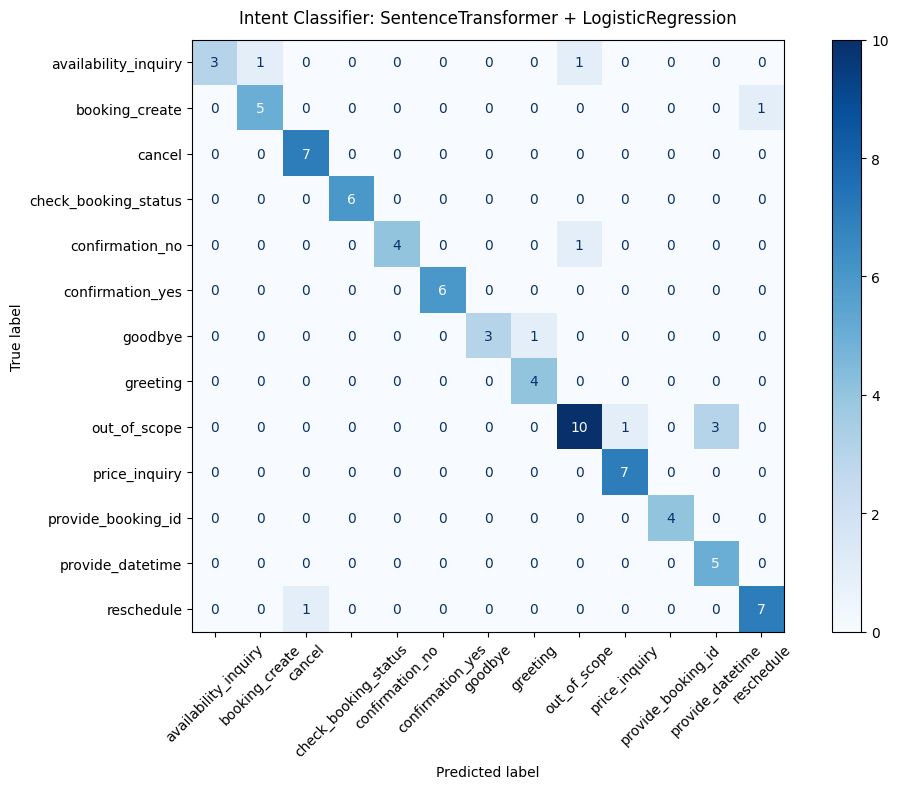

Saved: reports/intent_confusion_matrix.png

Context vs No-Context comparison:
Message            State                  Intent                    Conf
---------------------------------------------------------------------------
Yes                IDLE                   out_of_scope              0.415
Yes                RESCHEDULE_CONFIRM     out_of_scope              0.292
BK-001             IDLE                   provide_booking_id        0.444
BK-001             CANCEL_ASK_BK_ID       provide_booking_id        0.385
move it            IDLE                   out_of_scope              0.475
shift session      IDLE                   out_of_scope              0.371


In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay,
                              precision_score, recall_score, f1_score,
                              classification_report)
from sklearn.model_selection import train_test_split

X_train_e, X_test_e, y_train_e, y_test_e = train_test_split(
    X_emb, y_label, test_size=0.25, stratify=y_label, random_state=42
)
clf_eval = LogisticRegression(max_iter=2000, C=5.0, random_state=42)
clf_eval.fit(X_train_e, y_train_e)
y_pred_e = clf_eval.predict(X_test_e)

p = precision_score(y_test_e, y_pred_e, average="weighted", zero_division=0)
r = recall_score(y_test_e,    y_pred_e, average="weighted", zero_division=0)
f1 = f1_score(y_test_e,       y_pred_e, average="weighted", zero_division=0)
print(f"Precision : {p:.3f}")
print(f"Recall    : {r:.3f}")
print(f"F1        : {f1:.3f}")
print()
print(classification_report(y_test_e, y_pred_e, target_names=le_intent.classes_))

fig, ax = plt.subplots(figsize=(11, 8))
cm = confusion_matrix(y_test_e, y_pred_e)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le_intent.classes_)
disp.plot(ax=ax, xticks_rotation=45, colorbar=True, cmap="Blues")
ax.set_title("Intent Classifier: SentenceTransformer + LogisticRegression", pad=12)
plt.tight_layout()
plt.savefig("reports/intent_confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: reports/intent_confusion_matrix.png")

print("")
print("Context vs No-Context comparison:")
test_cases = [
    ("Yes",           "IDLE",               ""),
    ("Yes",           "RESCHEDULE_CONFIRM", "Reschedule BK-001 to Apr 5? Confirm?"),
    ("BK-001",        "IDLE",               ""),
    ("BK-001",        "CANCEL_ASK_BK_ID",  "Please provide your booking ID."),
    ("move it",       "IDLE",               ""),
    ("shift session", "IDLE",               ""),
]
print("{:<18} {:<22} {:<25} {}".format("Message", "State", "Intent", "Conf"))
print("-" * 75)
for msg, state, last_bot in test_cases:
    intent, conf = classify_with_context(msg, state, last_bot)
    print("{:<18} {:<22} {:<25} {:.3f}".format(msg, state, intent, conf))


## 3.9 - Save Model

Saves the trained chatbot model to models/chatbot_model.pkl for use by the API.

In [ ]:
import joblib

chatbot_artifact = {
    # â”€â”€ Classifier â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
    "st_model_name":         ST_MODEL_NAME,         # "all-MiniLM-L6-v2"
    "classifier":            clf,                   # LogisticRegression on embeddings
    "label_encoder":         le_intent,
    "intents":               INTENTS,
    "confidence_threshold":  BlysChat.CONFIDENCE_THRESHOLD,
    "prior_alpha":           PRIOR_ALPHA,
    "state_priors":          STATE_PRIORS,
    # â”€â”€ Response templates â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
    "response_templates":    RESPONSE_TEMPLATES,
    "price_list":            PRICE_LIST,
    "services":              SERVICES,
    # â”€â”€ Metadata â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
    "model_version":         "3.0.0",
    "architecture":          "SentenceTransformer + LogReg + Context Window + State Priors",
    "evaluation": {
        "cv_f1_mean":  round(float(cv_f1.mean()), 4),
        "cv_f1_std":   round(float(cv_f1.std()),  4),
        "n_intents":   len(INTENTS),
        "n_examples":  len(X_text),
        "embedding_dim": int(X_emb.shape[1]),
    }
}

joblib.dump(chatbot_artifact, "models/chatbot_model.pkl")
print("Saved: models/chatbot_model.pkl")
print()
print("=== Artifact contents ===")
for k, v in chatbot_artifact.items():
    if k == "evaluation":
        print(f"  {k}:")
        for ek, ev in v.items():
            print(f"      {ek}: {ev}")
    elif k in ("state_priors", "response_templates"):
        print(f"  {k}: dict[{len(v)} keys]")
    elif isinstance(v, list):
        print(f"  {k}: list[{len(v)}]")
    else:
        print(f"  {k}: {type(v).__name__} â€” {str(v)[:60]}")

Saved: models/chatbot_model.pkl

=== Artifact contents ===
  st_model_name: str â€” all-MiniLM-L6-v2
  classifier: LogisticRegression â€” LogisticRegression(C=5.0, max_iter=2000, random_state=42)
  label_encoder: LabelEncoder â€” LabelEncoder()
  intents: list[13]
  confidence_threshold: float â€” 0.35
  prior_alpha: float â€” 0.3
  state_priors: dict[12 keys]
  response_templates: dict[27 keys]
  price_list: dict â€” {'Massage': '$80 â€“ $150  (60â€“90 min)', 'Swedish Massage'
  services: list[9]
  model_version: str â€” 3.0.0
  architecture: str â€” SentenceTransformer + LogReg + Context Window + State Priors
  evaluation:
      cv_f1_mean: 0.8622
      cv_f1_std: 0.0191
      n_intents: 13
      n_examples: 322
      embedding_dim: 384


: 